In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/review-intelligence-system

/content/drive/MyDrive/review-intelligence-system


In [3]:
!ls

app  data  notebooks  outputs  README.md  requirements.txt  src  venv


In [4]:
!pip install transformers datasets accelerate -q

In [5]:
!pip install scikit-learn seaborn -q

In [6]:
import torch

torch.cuda.is_available()

True

In [7]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments)

In [8]:
%cd /content/drive/MyDrive/review-intelligence-system/notebooks

/content/drive/MyDrive/review-intelligence-system/notebooks


In [9]:
data = pd.read_csv('../data/processed/data_clean.csv')

data=data[["cleaned_text","category_encoded"]].dropna()

data.head()


,cleaned_text,category_encoded
0,over 4 million americans roll up sleeves for o...,10
1,american airlines flyer charged banned for lif...,10
2,23 of the funniest tweets about cats and dogs ...,3
3,the funniest tweets from parents this week sep...,5
4,woman who called cops on black birdwatcher los...,10


In [10]:
data_sample=data.sample(n=40000, random_state=42)
data_sample["category_encoded"].value_counts()

,count
category_encoded,
10,9475
8,6745
3,4865
7,4662
5,3804
14,3002
1,1498
9,1238
13,972


In [11]:
x_train,x_test,y_train,y_test=train_test_split(data_sample["cleaned_text"],data_sample["category_encoded"],
                                               test_size=0.2,random_state=42,
                                               stratify=data_sample["category_encoded"])

In [12]:
#Transformer en format Hugging Face Dataset
# Hugging Face Dataset nécessite un format spécifique, nous allons donc convertir nos données d'entraînement et de test en deux tableaux, puis les transformer en Dataset.
train_df=pd.DataFrame({"text":x_train,"label":y_train})
test_df=pd.DataFrame({"text":x_test,"label":y_test})

train_dataset=Dataset.from_pandas(train_df)
test_dataset=Dataset.from_pandas(test_df)

In [13]:
#charger le tokenizer distilbert-base-uncased

model_name="distilbert-base-uncased"
tokenizer=AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [14]:
#tokenization
#transformer le texte en token(des nombres comprehensibles par le modele)
def tokenize_function(examples):
    return tokenizer(examples["text"],
                      padding="max_length", #si le texte est plus court que la longueur max, il sera complété avec des zéros
                      truncation=True,#si le texte depasse la longueur max, il sera tronqué
                      max_length=128)

#map sert à appliquer la fonction de tokenization à chaque exemple du dataset
train_dataset= train_dataset.map(tokenize_function, batched=True)
test_dataset= test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/32000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

In [15]:
num_labels=data_sample["category_encoded"].nunique()#compter le nombre de classes uniques dans les labels
#from_pretrained est pour charger un modele pré-entrainé
model=AutoModelForSequenceClassification.from_pretrained(
                                                         model_name,
                                                         num_labels=num_labels#le modele crée automatiquement un nombre de neurones de sortie égal au nombre de classes

                                                         )

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [16]:
def compute_metrics(eval_pred):
    #les logits sont les sorties brutes du modele et les labels sont les vraies étiquettes
    logits,labels=eval_pred
    predictions=np.argmax(logits, axis=-1)#argmax pour obtenir la classe prédite (celle avec la plus grande probabilité)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro")
    }


In [17]:
#configuration de l'entraînement

Training_args=TrainingArguments(
    output_dir="../outputs/models/distilbert_news",#le dossier où les modèles seront sauvegardés
    eval_strategy="epoch",#évaluer le modèle à la fin de chaque epoch
    save_strategy="epoch",#sauvegarder le modèle à la fin de chaque epoch
    learning_rate=2e-5,#vitesse d'apprentissage
    per_device_train_batch_size=16,#taille du batch pour l'entraînement
    per_device_eval_batch_size=16,#taille du batch pour l'évaluation
    num_train_epochs=5,
    weight_decay=0.01,#pour éviter le surapprentissage
    load_best_model_at_end=True,#charger le meilleur modèle à la fin de l'entraînement ou on a la meilleur epoch
    logging_dir="../outputs/logs",
    logging_steps=50,#log tous les 50 steps
    report_to=[]#ne pas utiliser de système de reporting

    )

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [18]:
#trainer

trainer=Trainer(
    model=model,
    args=Training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

In [19]:
#entrainer
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.926030,0.926236,0.720000,0.578741
2,0.668678,0.907344,0.734375,0.600922
3,0.505958,0.960616,0.731125,0.603330
4,0.370558,1.051386,0.730125,0.609468
5,0.245148,1.110433,0.728875,0.607564


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=10000, training_loss=0.5873760699272156, metrics={'train_runtime': 2272.1976, 'train_samples_per_second': 70.416, 'train_steps_per_second': 4.401, 'total_flos': 5299924377600000.0, 'train_loss': 0.5873760699272156, 'epoch': 5.0})

In [20]:
eval_results=trainer.evaluate()
print(eval_results)

{'eval_loss': 0.9072738289833069, 'eval_accuracy': 0.734375, 'eval_f1_macro': 0.6008915455093258, 'eval_runtime': 35.6296, 'eval_samples_per_second': 224.533, 'eval_steps_per_second': 14.033, 'epoch': 5.0}


In [21]:
#prediction + classification report
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.59      0.61       147
           1       0.62      0.62      0.62       300
           2       0.49      0.49      0.49        75
           3       0.71      0.72      0.72       973
           4       0.46      0.70      0.55       165
           5       0.78      0.78      0.78       761
           6       0.62      0.05      0.09       107
           7       0.77      0.78      0.77       933
           8       0.80      0.90      0.85      1349
           9       0.57      0.29      0.39       248
          10       0.82      0.81      0.81      1895
          11       0.63      0.51      0.56        99
          12       0.54      0.45      0.49       154
          13       0.68      0.75      0.71       194
          14       0.57      0.56      0.57       600

    accuracy                           0.73      8000
   macro avg       0.65      0.60      0.60      8000
weighted avg       0.73   

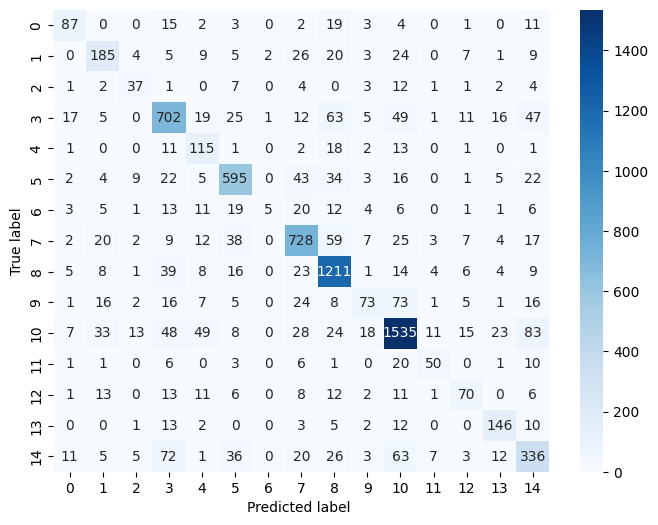

In [22]:
cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted label ")
plt.ylabel("True label")
plt.show()

In [23]:
logs=pd.DataFrame(trainer.state.log_history)
logs

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,2.409320,4.238228,1.990200e-05,0.025,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.977254,4.003785,1.980200e-05,0.050,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.706634,5.326247,1.970200e-05,0.075,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.564518,8.471622,1.960200e-05,0.100,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.485606,8.908574,1.950200e-05,0.125,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,0.254502,10.183916,1.020000e-07,4.975,9950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203,0.245148,3.623914,2.000000e-09,5.000,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
204,NaN,NaN,NaN,5.000,10000,1.110433,0.728875,0.607564,35.1683,227.477,14.217,NaN,NaN,NaN,NaN,NaN
205,NaN,NaN,NaN,5.000,10000,NaN,NaN,NaN,NaN,NaN,NaN,2272.1976,70.416,4.401,5.299924e+15,0.587376


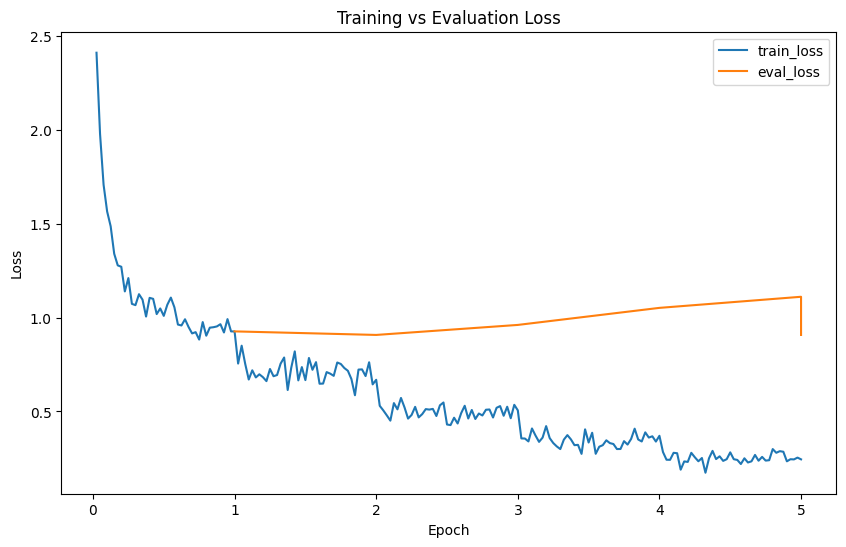

In [24]:
train_loss=logs[logs["loss"].notna()][["epoch","loss"]]#garder seulement les lignes ou la colonne loss existe
eval_loss=logs[logs["eval_loss"].notna()][["epoch","eval_loss"]]
plt.figure(figsize=(10,6))
plt.plot(train_loss["epoch"],train_loss["loss"],label="train_loss")
plt.plot(eval_loss["epoch"],eval_loss["eval_loss"],label="eval_loss")
plt.title("Training vs Evaluation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()